# Statistics of NMRlipids databank

This notebook plots:
1. Distributions of simulation lengths, number of atoms and trajectory sizes
2. Distribution of number of lipid components
3. Available single component bilayers and binary lipid mixtures
4. Pie diagram of temperatures

# Initializing databank

In [1]:
from DatabankLib.protein_functions import *
import yaml

databankPath = "/home/sosamuli/work/NMRlipids/IDPdatabank/"  # this is the local path for the cloned Databank
os.environ["NMLDB_ROOT_PATH"] = "/home/sosamuli/work/NMRlipids/IDPdatabank/"

#databankPath = "/home/sosamuli/work/NMRlipids/IDPsimBank/"  # this is the local path for the cloned Databank
#os.environ["NMLDB_ROOT_PATH"] = "/home/sosamuli/work/NMRlipids/IDPsimBank/"



# These two lines include core Databank routines and Databank API
from DatabankLib.core import *
from DatabankLib.databankLibrary import *
# This is for plotting
from DatabankLib.databankio import *
from DatabankLib.plottings import plotSimulation
#from IPython.display import display, Markdown

# This initializes the databank and stores the information of all simulations into a list.
# Each list item contains the information from README.yaml file of the given simulation.
systems = initialize_databank()


/home/sosamuli/anaconda3/envs/IDPdatabank/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/sosamuli/anaconda3/envs/IDPdatabank/lib/python3.11/site-packages/Bio/Application/__init__.py:39: BiopythonDeprecationWarning: The Bio.Application modules and modules relying on it have been deprecated.

Due to the on going maintenance burden of keeping command line application
wrappers up to date, we have decided to deprecate and eventually remove these
modules.

We instead now recommend building your command line and invoking it directly
with the subprocess module.
  warnings.warn(
Bio.pairwise2 has been deprecated, and we intend to remove it in a future release of Biopython. As an alternative, please consider using Bio.Align.PairwiseAligner as a replacement, and contact the Biopython developers if you still

Databank initialized from the folder: /home/sosamuli/work/NMRlipids/IDPdatabank/Data/Simulations


# Plot distributions of simulation lengths, number of atoms and trajectory sizes

Number of entries:  445
Total size of trajectories:  464.778481349349 Gb
Total time of trajectories:  633554.8300000001 ns


Text(0, 0.5, 'Distribution')

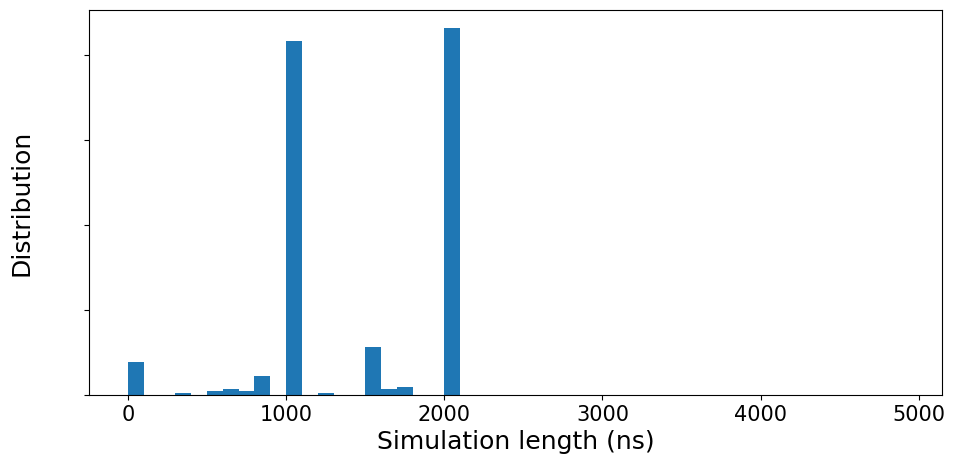

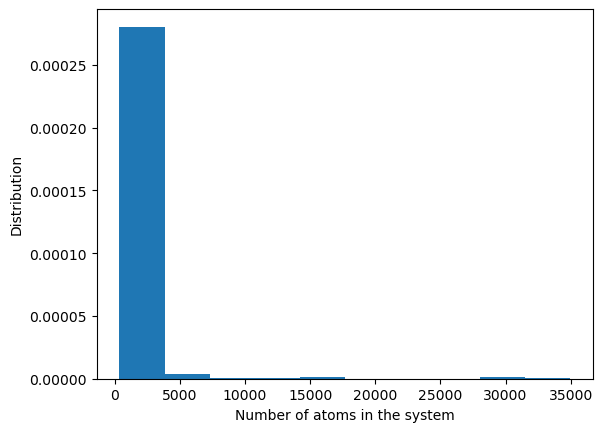

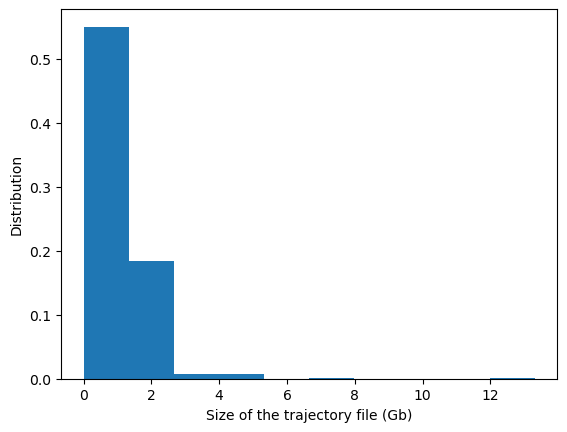

In [2]:
SimulationLengths = []
NumberOfAtoms = []
SizeOfTrajectories = []

# Loop over simulations in the Databank
for system in systems:
    SimulationLengths.append(system['TRJLENGTH']*0.001)
    NumberOfAtoms.append(system['NUMBER_OF_ATOMS'])
    SizeOfTrajectories.append(system['TRAJECTORY_SIZE']/(1024*1024*1024))
    
print("Number of entries: ",len(systems))
print("Total size of trajectories: ",str(np.sum(SizeOfTrajectories)) + ' Gb')
print("Total time of trajectories: ",str(np.sum(SimulationLengths)) + ' ns')

plt.figure(figsize=(11,5))
distSIMl = plt.hist(SimulationLengths, density=True,bins=np.arange(0,5000,100))
plt.xlabel('Simulation length (ns)', fontsize=18)
plt.ylabel('Distribution', fontsize=18)
plt.yticks(color='w')
plt.xticks(fontsize=15)
plt.figure()
distNatoms = plt.hist(NumberOfAtoms, density=True)
plt.xlabel('Number of atoms in the system')
plt.ylabel('Distribution')
plt.figure()
disttrjSIZE = plt.hist(SizeOfTrajectories, density=True)
plt.xlabel('Size of the trajectory file (Gb)')
plt.ylabel('Distribution')

# Plot distribution of different proteins

{'Charged sequence with tris': 3, 'KRS1-72_salt': 25, 'asyn_salt': 25, 'SNAP25_noions': 24, 'CDNF': 25, 'KRS1-72': 25, 'wrapping silk (AcSp1)': 25, 'Protein linker': 7, 'asyn': 25, 'ChiZ_salt': 25, 'ChiZ1-64': 25, 'Charged sequence with NaCl': 6, 'calmodulin': 25, 'silk protein': 67, 'MANF': 25, 'TonBCTD': 25, 'icl2': 25, 'EN2': 25, 'Charged protonated sequence with CaCl': 1, 'Charged sequence with NaCl and phosphate': 2, 'Charged sequence with CaCl': 1, 'Charged protonated sequence with NaCl': 1, 'Charged sequence with CaCl and phosphate': 1, 'TonB': 1, 'Charged sequence protonated peptide': 1, 'TonB low pH with CaCl': 1, 'Charged sequence peptide': 1, 'TonB low pH with NaCl': 1, 'Calmodulin': 1, 'TonB with CaCl, deprotonated': 1}


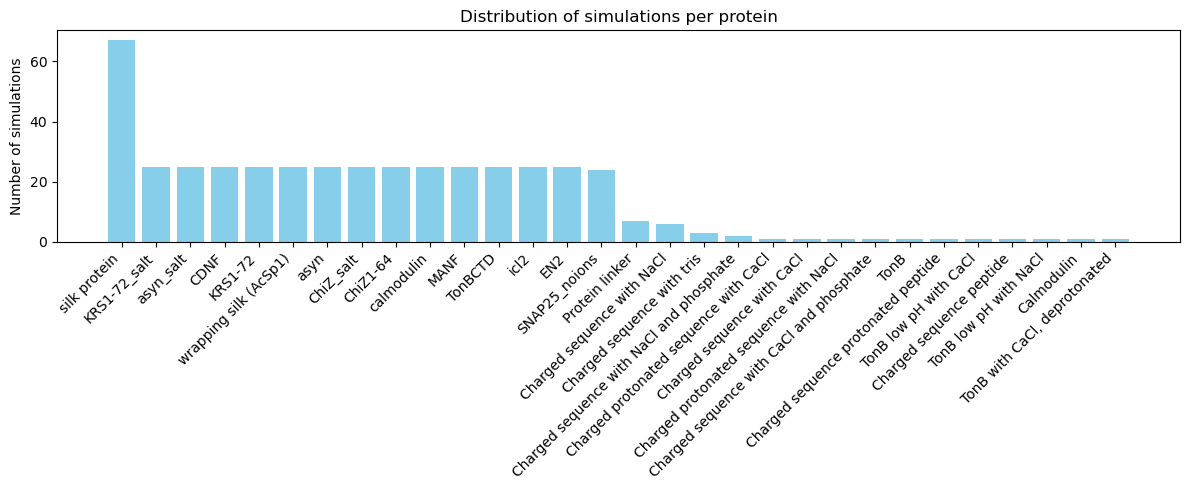

In [3]:
# Loop over simulations in the Databank

system_descriptions = {}

for system in systems:
    #print(system['COMPOSITION']['PROTEIN']['SEQUENCE'])
    system_description = system['SYSTEM']
    if system_description not in system_descriptions:
        system_descriptions[system_description] = 1
    else:
        system_descriptions[system_description] += 1
    
    #print(system['FF'])
print(system_descriptions)
    
# Your dictionary
protein_counts = system_descriptions

# Sort by counts (optional)
sorted_items = dict(sorted(protein_counts.items(), key=lambda x: x[1], reverse=True))

# Create bar plot
plt.figure(figsize=(12,5))
plt.bar(sorted_items.keys(), sorted_items.values(), color='skyblue')

plt.ylabel("Number of simulations")
plt.title("Distribution of simulations per protein")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Show available simulations for Uniprot IDs

In [4]:
import re
import yaml
import pandas as pd
from collections import defaultdict

# -----------------------------
# helpers
# -----------------------------

def parse_uniprot(title):
    uid = re.search(r'\|([^|]+)\|', title)
    name = re.search(r'RecName: Full=([^;]+)', title)

    return (
        uid.group(1) if uid else "",
        name.group(1) if name else ""
    )

def has_data(block):
    """
    True if any list in experiment block is non-empty
    """
    if not isinstance(block, dict):
        return False

    for v in block.values():
        if isinstance(v, list) and len(v) > 0:
            return True
    return False

def yesno(x):
    return "Yes" if x else "No"

# -----------------------------
# grouping
# -----------------------------

groups = defaultdict(lambda: {
    "system_ids": [],
    "chemical_shift": False,
    "saxs": False,
    "spin_relaxation": False
})

# -----------------------------
# loop over systems
# -----------------------------

for system in systems:
    path = databankPath + 'Data/Simulations/' + system['path'] + 'cross_link_data.yaml'

    try:
        with open(path) as f:
            data = yaml.safe_load(f)
    except Exception:
        continue

    uniprot_hits = data.get("uniprot", [])
    if not uniprot_hits:
        continue

    best = max(uniprot_hits, key=lambda x: x["similarity_%"])
    uid, pname = parse_uniprot(best["title"])
    sim = best["similarity_%"]

    key = (uid, pname, sim)

    groups[key]["system_ids"].append(system["ID"])

    # -----------------------------
    # experiments
    # -----------------------------
    exp = system.get("EXPERIMENT", {})

    groups[key]["chemical_shift"] |= has_data(exp.get("chemical_shift", {}))
    groups[key]["saxs"] |= has_data(exp.get("saxs", {}))
    groups[key]["spin_relaxation"] |= has_data(exp.get("spin_relaxation", {}))

# -----------------------------
# build dataframe
# -----------------------------

rows = []

for (uid, pname, sim), v in groups.items():
    rows.append({
        "UniProt ID": uid,
        "Protein name": pname,
        "System IDs": ", ".join(map(str, v["system_ids"])),
        "Similarity (%)": sim,
        "Chemical shift": yesno(v["chemical_shift"]),
        "SAXS": yesno(v["saxs"]),
        "Spin relaxation": yesno(v["spin_relaxation"]),
    })

df = pd.DataFrame(rows)

# optional sorting
df = df.sort_values(
    ["Protein name", "Similarity (%)"],
    ascending=[True, False]
)

df



,UniProt ID,Protein name,System IDs,Similarity (%),Chemical shift,SAXS,Spin relaxation
7,P37840.1,Alpha-synuclein,"53, 104, 106, 57, 61, 62, 63, 66, 110, 112, 71...",100.00,Yes,Yes,Yes
2,P37377.1,Alpha-synuclein [Rattus norvegicus],"103, 109, 65, 73, 74, 113, 114, 118, 123, 88, ...",100.00,Yes,Yes,Yes
6,P37377.1,Alpha-synuclein [Rattus norvegicus],"52, 105, 111, 69, 76, 117, 77, 81, 119, 86, 91...",99.29,Yes,Yes,Yes
17,A0A2R2JFW7.1,Arginase [Glaciozyma antarctica PI12],"327, 329, 330, 333, 338, 340, 341, 344, 346, 3...",100.00,Yes,No,No
9,P0DP23.1,Calmodulin-1 [Homo sapiens] >sp|P0DP24.1| RecN...,"191, 192, 194, 196, 198, 199, 203, 205, 208, 2...",100.00,Yes,No,Yes
11,I6YA32.1,Cell wall hydrolase ChiZ [Mycobacterium tuberc...,"178, 156, 7, 11, 158, 12, 161, 18, 19, 22, 24,...",100.00,No,Yes,Yes
8,I6YA32.1,Cell wall hydrolase ChiZ [Mycobacterium tuberc...,"152, 2, 3, 4, 154, 155, 6, 157, 10, 159, 160, ...",95.31,No,Yes,Yes
4,Q49AH0.2,Cerebral dopamine neurotrophic factor,"323, 328, 288, 331, 332, 289, 290, 299, 339, 3...",100.00,Yes,No,Yes
21,Q49AH0.2,Cerebral dopamine neurotrophic factor,"353, 307, 364, 371, 292",98.14,Yes,No,Yes
16,Q05917.2,Homeobox protein engrailed-2,"410, 415, 416, 417, 405, 406, 411, 418, 407, 4...",100.00,Yes,No,Yes


In [6]:
import matplotlib.pyplot as plt
import textwrap

# -----------------------------
# Helper functions
# -----------------------------

def shorten_name(name, max_words=10, wrap_width=45):
    """Truncate a protein name to max_words and wrap it."""
    words = str(name).split()
    if len(words) > max_words:
        name = " ".join(words[:max_words]) + " ..."
    return "\n".join(textwrap.wrap(name, width=wrap_width))


def compress_ids(ids):
    """
    Convert a list of integers like
    [1,2,3,5,6,8]
    into
    '1-3, 5-6, 8'
    """
    ids = sorted(set(int(i) for i in ids))

    if not ids:
        return ""

    ranges = []
    start = prev = ids[0]

    for n in ids[1:]:
        if n == prev + 1:
            prev = n
        else:
            if start == prev:
                ranges.append(str(start))
            else:
                ranges.append(f"{start}-{prev}")
            start = prev = n

    # Add final range
    if start == prev:
        ranges.append(str(start))
    else:
        ranges.append(f"{start}-{prev}")

    return ", ".join(ranges)


def format_system_ids(system_ids, wrap_width=50):
    """
    Compress consecutive IDs into ranges and wrap the text.
    """
    ids = [int(i.strip()) for i in str(system_ids).split(",")]
    compressed = compress_ids(ids)
    return "\n".join(textwrap.wrap(compressed, width=wrap_width))


# -----------------------------
# Prepare dataframe for plotting
# -----------------------------

df_plot = df.copy()

# Shorten and wrap protein names
df_plot["Protein name"] = df_plot["Protein name"].apply(
    lambda x: shorten_name(x, max_words=10, wrap_width=45)
)

# Compress and wrap System IDs
df_plot["System IDs"] = df_plot["System IDs"].apply(
    lambda x: format_system_ids(x, wrap_width=50)
)

# -----------------------------
# Create figure
# -----------------------------

fig_height = max(4, len(df_plot) * 0.45)

fig, ax = plt.subplots(figsize=(15, fig_height))
ax.axis("off")

table = ax.table(
    cellText=df_plot.values,
    colLabels=df_plot.columns,
    loc="center",
    cellLoc="left"
)

# Font settings
table.auto_set_font_size(False)
table.set_fontsize(8)

# Increase row height
table.scale(1, 2.3)

# -----------------------------
# Column widths
# -----------------------------

col_widths = {
    0: 0.13,  # UniProt ID
    1: 0.32,  # Protein name
    2: 0.28,  # System IDs
    3: 0.08,  # Similarity
    4: 0.08,  # Chemical shift
    5: 0.05,  # SAXS
    6: 0.09,  # Spin relaxation
}

for (row, col), cell in table.get_celld().items():
    if col in col_widths:
        cell.set_width(col_widths[col])

    cell.get_text().set_wrap(True)

    if row == 0:
        cell.set_text_props(weight="bold")

# -----------------------------
# Save
# -----------------------------

plt.savefig("table.pdf", bbox_inches="tight")
plt.close()

print("Saved table to table.pdf")

Saved table to table.pdf


# Show available simulations for PDB IDs

In [46]:
import re
import yaml
import pandas as pd
from collections import defaultdict

# -----------------------------
# helpers
# -----------------------------

def parse_pdb(title):
    pid = re.search(r'pdb\|([^|]+)\|', title)
    name = re.search(r'Chain [A-Z],\s*([^>\[]+)', title)

    return (
        pid.group(1) if pid else "",
        name.group(1).strip() if name else ""
    )

def has_data(block):
    """
    Returns True if experiment block contains any non-empty list.
    """
    if not isinstance(block, dict):
        return False

    for v in block.values():
        if isinstance(v, list) and len(v) > 0:
            return True
    return False

def yesno(x):
    return "Yes" if x else "No"

# -----------------------------
# grouping container
# -----------------------------

groups = defaultdict(lambda: {
    "system_ids": [],
    "chemical_shift": False,
    "saxs": False,
    "spin_relaxation": False
})

# -----------------------------
# main loop
# -----------------------------

for system in systems:
    path = databankPath + 'Data/Simulations/' + system['path'] + 'cross_link_data.yaml'

    try:
        with open(path) as f:
            data = yaml.safe_load(f)
    except Exception:
        continue

    pdb_hits = data.get("pdb", [])
    if not pdb_hits:
        continue

    best = max(pdb_hits, key=lambda x: x["similarity_%"])
    pid, pname = parse_pdb(best["title"])
    sim = best["similarity_%"]

    key = (pid, pname, sim)

    groups[key]["system_ids"].append(system["ID"])

    # -----------------------------
    # experiments
    # -----------------------------
    exp = system.get("EXPERIMENT", {})

    groups[key]["chemical_shift"] |= has_data(exp.get("chemical_shift", {}))
    groups[key]["saxs"] |= has_data(exp.get("saxs", {}))
    groups[key]["spin_relaxation"] |= has_data(exp.get("spin_relaxation", {}))

# -----------------------------
# build dataframe
# -----------------------------

rows = []

for (pid, pname, sim), v in groups.items():
    rows.append({
        "PDB ID": pid,
        "Protein name": pname,
        "System IDs": ", ".join(map(str, v["system_ids"])),
        "Similarity (%)": sim,
        "Chemical shift": yesno(v["chemical_shift"]),
        "SAXS": yesno(v["saxs"]),
        "Spin relaxation": yesno(v["spin_relaxation"]),
    })

df = pd.DataFrame(rows)

# optional sorting
df = df.sort_values(
    ["Protein name", "Similarity (%)"],
    ascending=[True, False]
)

df

,PDB ID,Protein name,System IDs,Similarity (%),Chemical shift,SAXS,Spin relaxation
6,2MU3,Aciniform spidroin 1,"190, 193, 195, 188, 197, 200, 201, 202, 204, 1...",100.00,No,No,No
8,1XQ8,Alpha-synuclein,"53, 104, 106, 57, 61, 62, 63, 66, 110, 112, 71...",100.00,Yes,Yes,Yes
2,8UIE,Alpha-synuclein,"103, 109, 65, 73, 74, 113, 114, 118, 123, 88, ...",99.29,Yes,Yes,Yes
7,8UIE,Alpha-synuclein,"52, 105, 111, 69, 76, 117, 77, 81, 119, 86, 91...",98.57,Yes,Yes,Yes
11,2XFF,BETA-AMYLASE,"324, 293, 294, 325, 295, 326, 296, 297, 298, 3...",55.17,No,No,No
4,4BIT,CEREBRAL DOPAMINE NEUROTROPHIC FACTOR,"323, 328, 288, 331, 332, 289, 290, 299, 339, 3...",100.00,Yes,No,Yes
10,6O20,Calmodulin,"191, 192, 194, 196, 198, 199, 203, 205, 208, 2...",100.00,Yes,No,Yes
19,2LPN,Cerebral dopamine neurotrophic factor,"353, 307, 364, 371",99.05,Yes,No,Yes
16,5ZVL,Glutaredoxin,"327, 329, 330, 333, 338, 340, 341, 344, 346, 3...",97.83,No,No,No
15,3ZOB,HOMEOBOX PROTEIN ENGRAILED-2,"410, 415, 416, 417, 405, 406, 411, 418, 407, 4...",95.31,Yes,No,Yes


# Plot distribution of different force fields

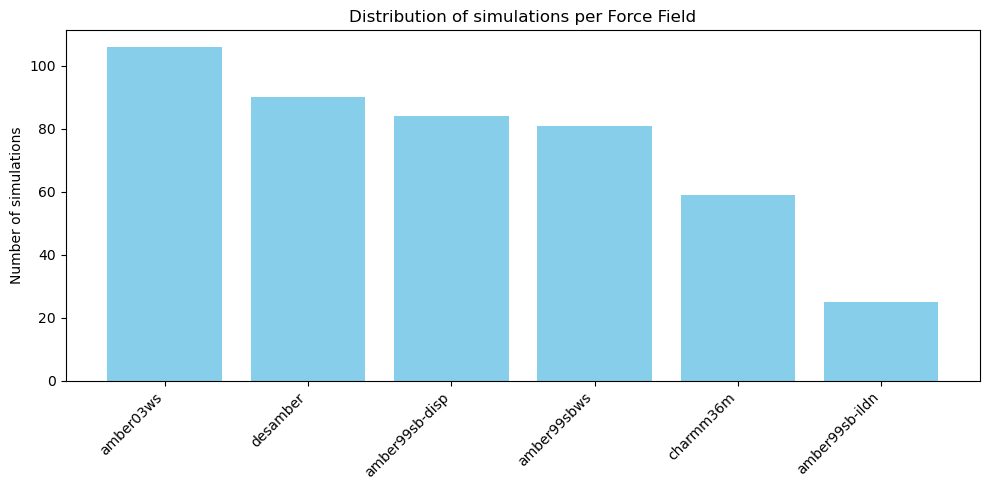

In [5]:
import matplotlib.pyplot as plt

# Mapping of variant names to canonical force field names
ff_canonical = {
    'amberff03ws': 'amber03ws',
    'amber03ws': 'amber03ws',
    'amber99sbws': 'amber99sbws',
    'amber99sb-disp': 'amber99sb-disp',
    'desamber': 'desamber',
    'charmm36m': 'charmm36m',
}

# Count simulations per (canonical) force field
system_descriptions = {}

for system in systems:
    ff = str(system['FF']).strip().lower()  # normalize
    ff = ff_canonical.get(ff, ff)          # map to canonical name
    
    if ff in ['none','nan','unknown']:
        continue  # skip invalid FFs
    
    if ff not in system_descriptions:
        system_descriptions[ff] = 1
    else:
        system_descriptions[ff] += 1

# Your dictionary
protein_counts = system_descriptions

# Sort by counts (optional)
sorted_items = dict(sorted(protein_counts.items(), key=lambda x: x[1], reverse=True))

# Create bar plot
plt.figure(figsize=(10,5))
plt.bar(sorted_items.keys(), sorted_items.values(), color='skyblue')

plt.ylabel("Number of simulations")
plt.title("Distribution of simulations per Force Field")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

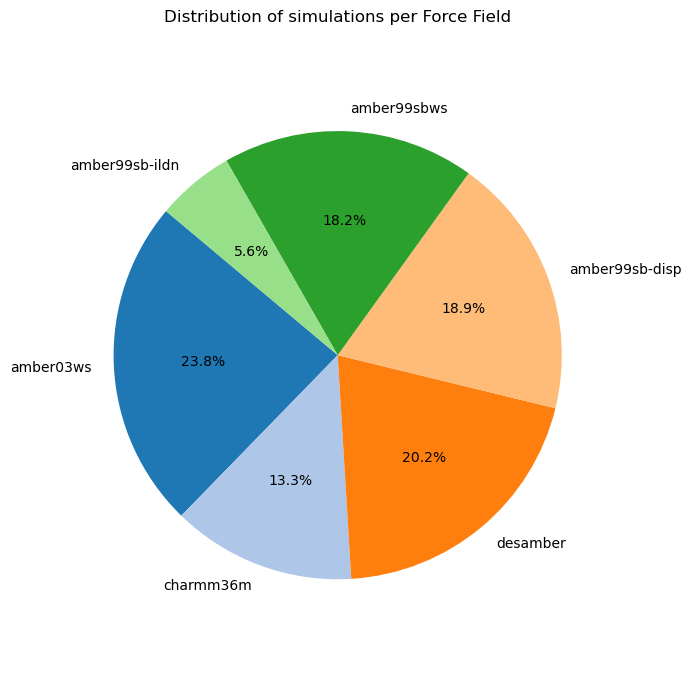

In [6]:
import matplotlib.pyplot as plt

# Use the same system_descriptions dictionary from your previous step
labels = list(system_descriptions.keys())
sizes = list(system_descriptions.values())

# Create pie chart
plt.figure(figsize=(7,7))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, colors=plt.cm.tab20.colors)
plt.title("Distribution of simulations per Force Field")
plt.axis('equal')  # Equal aspect ratio ensures the pie is circular
plt.tight_layout()
plt.show()

# Sequence information

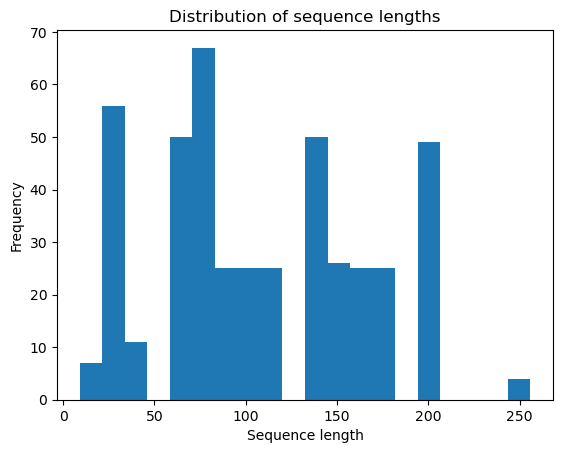

Sequence lengths:
[35, 72, 140, 206, 161, 72, 200, 9, 140, 140, 67, 206, 67, 35, 72, 67, 148, 206, 67, 148, 199, 206, 140, 72, 206, 33, 67, 72, 33, 171, 72, 72, 9, 33, 67, 72, 140, 92, 67, 72, 67, 67, 33, 67, 33, 100, 117, 33, 79, 161, 140, 100, 161, 33, 33, 117, 100, 140, 72, 72, 67, 117, 72, 148, 199, 199, 148, 100, 72, 67, 171, 67, 100, 33, 100, 79, 140, 67, 92, 79, 161, 117, 92, 92, 92, 67, 140, 35, 140, 161, 140, 67, 200, 161, 79, 67, 33, 72, 100, 35, 161, 206, 92, 148, 140, 148, 140, 171, 199, 67, 33, 117, 72, 72, 199, 33, 100, 9, 67, 92, 92, 161, 200, 100, 72, 33, 33, 67, 140, 171, 79, 67, 92, 148, 35, 72, 67, 171, 206, 206, 161, 140, 33, 140, 33, 72, 100, 140, 67, 206, 206, 67, 72, 199, 140, 33, 100, 200, 79, 72, 140, 117, 140, 148, 79, 161, 206, 33, 199, 33, 79, 117, 199, 100, 171, 92, 35, 140, 140, 140, 161, 148, 140, 79, 92, 148, 140, 171, 140, 140, 92, 206, 67, 148, 33, 117, 171, 67, 33, 92, 171, 206, 92, 148, 72, 171, 140, 67, 79, 79, 161, 148, 67, 72, 79, 100, 171, 171, 1

In [7]:
from collections import Counter

sequences = []

for system in systems:
    sequences.append(system['COMPOSITION']['PROTEIN']['SEQUENCE'])

#print(sequences)

# --- 1. Compute sequence lengths ---
lengths = [len(seq) for seq in sequences]

# --- 2. Plot distribution of sequence lengths ---
plt.figure()
plt.hist(lengths, bins=20)
plt.xlabel("Sequence length")
plt.ylabel("Frequency")
plt.title("Distribution of sequence lengths")
plt.show()

# --- 3. Get unique sequences ---
unique_sequences = list(set(sequences))

# --- 4. Count number of unique sequences ---
num_unique_sequences = len(unique_sequences)

# --- 5. (Optional) Count frequency of each sequence ---
sequence_counts = Counter(sequences)

# --- Output results ---
print("Sequence lengths:")
print(lengths)

print("\nUnique sequences:")
print(unique_sequences)

print("\nNumber of unique sequences:")
print(num_unique_sequences)

print("\nSequence counts (frequency):")
print(sequence_counts)

# Disorder information

In [8]:
for system in systems:
    path = databankPath + '/Data/Simulations/' + (system['path'])
    secondary_structure_file = path + '/secondary_structure.yaml'
    with open(secondary_structure_file, "r") as f:
        secondary_structure_data = yaml.safe_load(f)
    print(secondary_structure_data)
    print()

{'10_V': {'B': 0.0, 'C': 1.0, 'E': 0.0, 'G': 0.0, 'H': 0.0, 'I': 0.0, 'S': 0.0, 'T': 0.0}, '11_P': {'B': 0.0, 'C': 1.0, 'E': 0.0, 'G': 0.0, 'H': 0.0, 'I': 0.0, 'S': 0.0, 'T': 0.0}, '12_K': {'B': 0.0, 'C': 1.0, 'E': 0.0, 'G': 0.0, 'H': 0.0, 'I': 0.0, 'S': 0.0, 'T': 0.0}, '13_P': {'B': 0.0, 'C': 1.0, 'E': 0.0, 'G': 0.0, 'H': 0.0, 'I': 0.0, 'S': 0.0, 'T': 0.0}, '14_K': {'B': 0.0, 'C': 1.0, 'E': 0.0, 'G': 0.0, 'H': 0.0, 'I': 0.0, 'S': 0.0, 'T': 0.0}, '15_P': {'B': 0.0, 'C': 1.0, 'E': 0.0, 'G': 0.0, 'H': 0.0, 'I': 0.0, 'S': 0.0, 'T': 0.0}, '16_K': {'B': 0.0, 'C': 1.0, 'E': 0.0, 'G': 0.0, 'H': 0.0, 'I': 0.0, 'S': 0.0, 'T': 0.0}, '17_P': {'B': 0.0, 'C': 1.0, 'E': 0.0, 'G': 0.0, 'H': 0.0, 'I': 0.0, 'S': 0.0, 'T': 0.0}, '18_K': {'B': 0.0, 'C': 1.0, 'E': 0.0, 'G': 0.0, 'H': 0.0, 'I': 0.0, 'S': 0.0, 'T': 0.0}, '19_P': {'B': 0.0, 'C': 1.0, 'E': 0.0, 'G': 0.0, 'H': 0.0, 'I': 0.0, 'S': 0.0, 'T': 0.0}, '1_K': {'B': 0.0, 'C': 1.0, 'E': 0.0, 'G': 0.0, 'H': 0.0, 'I': 0.0, 'S': 0.0, 'T': 0.0}, '20_K': {'

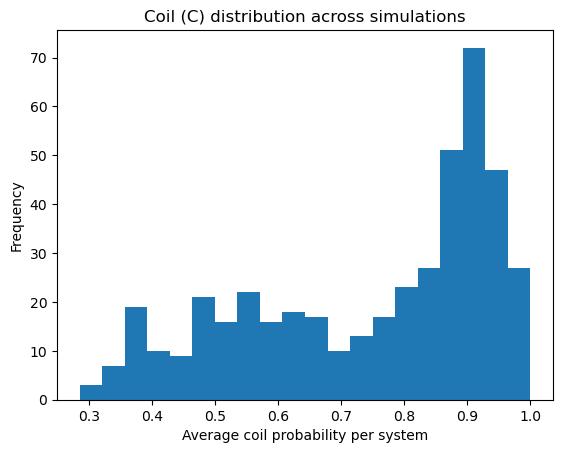

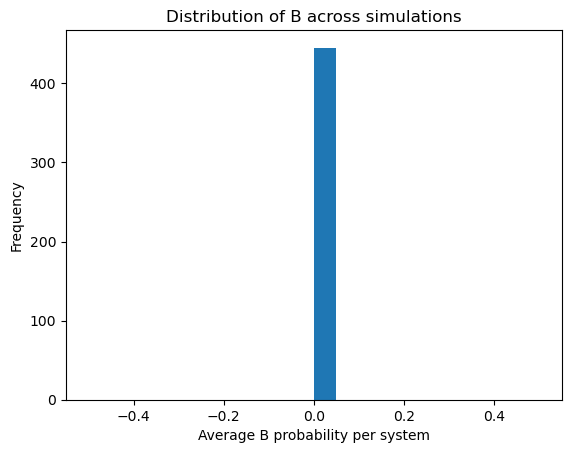

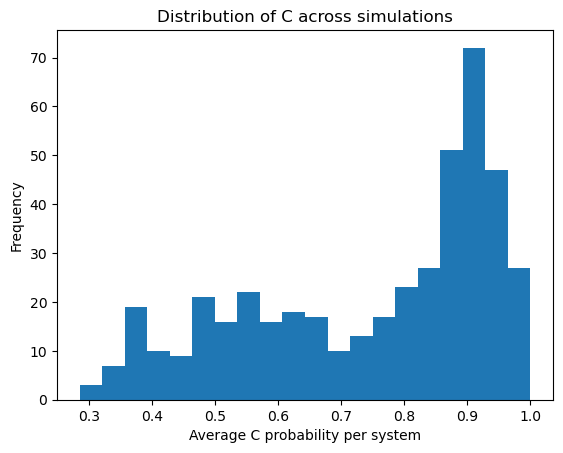

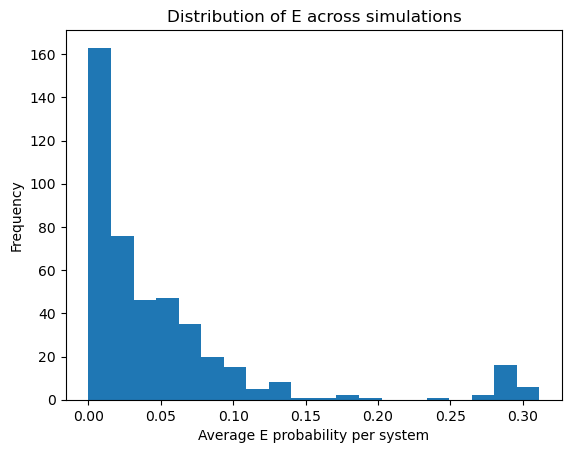

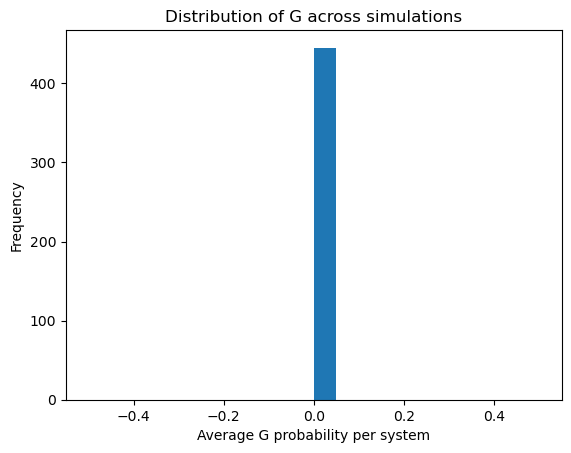

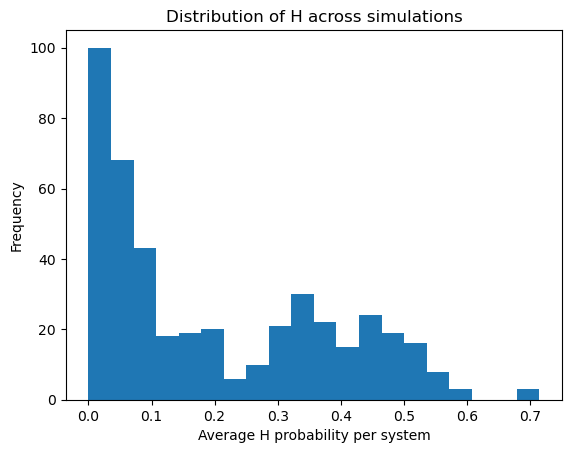

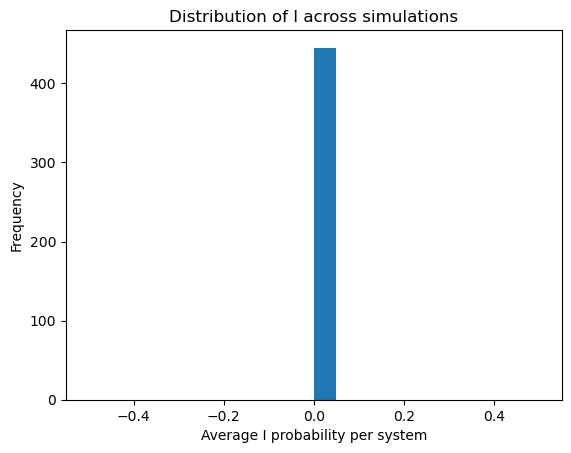

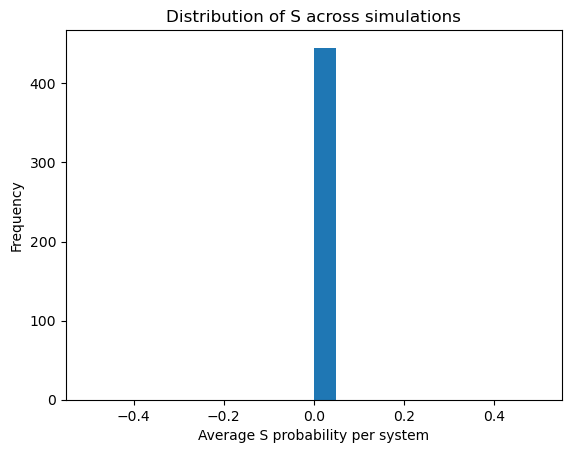

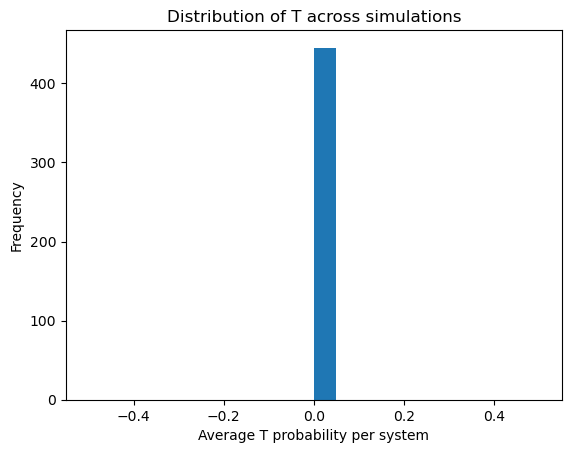

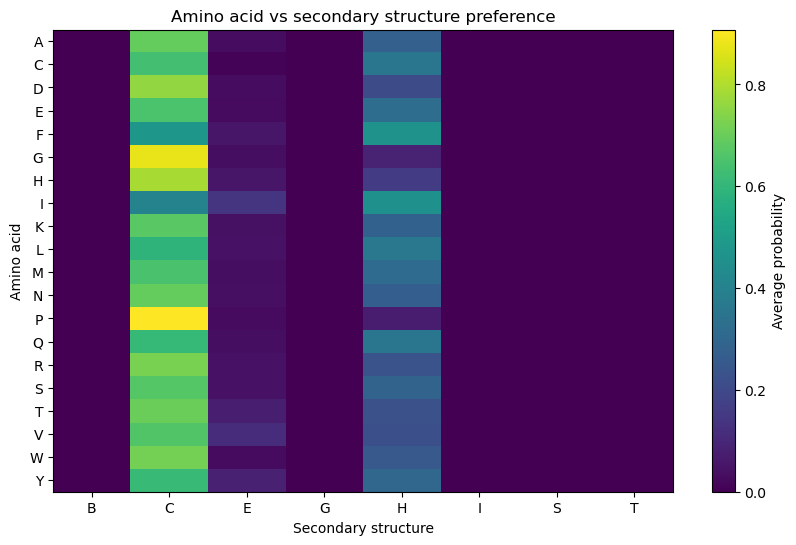

In [9]:
import os
import yaml
import matplotlib.pyplot as plt
from collections import defaultdict
import numpy as np

# --- Storage ---
avg_coil_per_system = []
ss_per_system = defaultdict(list)  
# ss_per_system["C"] = [avg_C_system1, avg_C_system2, ...]

aa_ss_counts = defaultdict(lambda: defaultdict(list))

# --- Loop over systems ---
for system in systems:
    path = os.path.join(databankPath, "Data", "Simulations", system["path"])
    secondary_structure_file = os.path.join(path, "secondary_structure.yaml")

    try:
        with open(secondary_structure_file, "r") as f:
            data = yaml.safe_load(f)
    except FileNotFoundError:
        print(f"Missing: {secondary_structure_file}")
        continue

    # --- per-system averages for each SS type ---
    ss_sums = defaultdict(list)

    for residue, ss_dict in data.items():
        for ss_type, prob in ss_dict.items():
            ss_sums[ss_type].append(prob)

            # AA-level aggregation
            aa = residue.split("_")[1]
            aa_ss_counts[aa][ss_type].append(prob)

    # compute system-level averages
    for ss_type, vals in ss_sums.items():
        ss_per_system[ss_type].append(np.mean(vals))

# =========================
# 📊 1. Coil distribution (existing)
# =========================
plt.figure()
plt.hist(ss_per_system["C"], bins=20)
plt.xlabel("Average coil probability per system")
plt.ylabel("Frequency")
plt.title("Coil (C) distribution across simulations")
plt.show()

# =========================
# 📊 2. Distribution for EACH SS type
# =========================
ss_types = sorted(ss_per_system.keys())

for ss in ss_types:
    plt.figure()
    plt.hist(ss_per_system[ss], bins=20)
    plt.xlabel(f"Average {ss} probability per system")
    plt.ylabel("Frequency")
    plt.title(f"Distribution of {ss} across simulations")
    plt.show()

# =========================
# 📊 3. AA vs SS heatmap (same as before)
# =========================

aa_list = sorted(aa_ss_counts.keys())
ss_types_matrix = sorted(next(iter(aa_ss_counts.values())).keys())

matrix = []

for aa in aa_list:
    row = []
    for ss in ss_types_matrix:
        values = aa_ss_counts[aa][ss]
        row.append(np.mean(values) if values else 0)
    matrix.append(row)

matrix = np.array(matrix)

plt.figure(figsize=(10, 6))
plt.imshow(matrix, aspect='auto')
plt.colorbar(label="Average probability")

plt.xticks(range(len(ss_types_matrix)), ss_types_matrix)
plt.yticks(range(len(aa_list)), aa_list)

plt.xlabel("Secondary structure")
plt.ylabel("Amino acid")
plt.title("Amino acid vs secondary structure preference")

plt.show()

In [10]:
def average_coil_probability(data):
    total = 0.0
    count = 0

    for probs in data.values():
        if "C" in probs:
            total += probs["C"]
            count += 1

    return total / count if count > 0 else 0.0


def plot_distribution(values):
    plt.figure()
    plt.hist(values, bins=20)  # adjust bins if needed
    plt.xlabel("Value")
    plt.ylabel("Frequency")
    plt.title("Distribution of Values")
    plt.show()

disordered_proteins = []
partially_folded_proteins = []
folded_proteins = []

for system in systems:
    path = databankPath + '/Data/Simulations/' + (system['path'])
    secondary_structure_file = path + '/secondary_structure.yaml'
    with open(secondary_structure_file, "r") as f:
        secondary_structure_data = yaml.safe_load(f)
    coil_probability = average_coil_probability(secondary_structure_data)

    system_name = system['SYSTEM']
    if coil_probability > 0.7 and system_name not in disordered_proteins:
        disordered_proteins.append(system_name)
    if coil_probability > 0.4 and coil_probability < 0.7 and system_name not in partially_folded_proteins:
        partially_folded_proteins.append(system_name)
    if coil_probability < 0.4 and system_name not in folded_proteins:
        folded_proteins.append(system_name)


#plot_distribution(tst)
print(disordered_proteins)
print()
print(partially_folded_proteins)
print()
print(folded_proteins)

['Charged sequence with tris', 'KRS1-72_salt', 'asyn_salt', 'SNAP25_noions', 'KRS1-72', 'Protein linker', 'asyn', 'ChiZ_salt', 'ChiZ1-64', 'Charged sequence with NaCl', 'silk protein', 'icl2', 'Charged protonated sequence with CaCl', 'wrapping silk (AcSp1)', 'Charged sequence with NaCl and phosphate', 'EN2', 'Charged sequence with CaCl', 'Charged protonated sequence with NaCl', 'Charged sequence with CaCl and phosphate', 'TonB', 'Charged sequence protonated peptide', 'TonB low pH with CaCl', 'Charged sequence peptide', 'TonB low pH with NaCl', 'TonB with CaCl, deprotonated']

['CDNF', 'wrapping silk (AcSp1)', 'SNAP25_noions', 'calmodulin', 'MANF', 'EN2', 'asyn_salt', 'asyn', 'TonBCTD', 'silk protein']

['asyn_salt', 'TonBCTD', 'calmodulin', 'SNAP25_noions', 'Calmodulin']


# Plot systems with experimental data available

In [49]:
# Loop over simulations in the Databank
system_IDs_with_cs_data = []
system_IDs_with_sr_data = []

for system in systems:
    if len(system['EXPERIMENT']['chemical_shift']['alignment_score']) > 0 :
        system_IDs_with_cs_data.append(system['ID'])
    if len(system['EXPERIMENT']['spin_relaxation']['alignment_score']) > 0:
        system_IDs_with_sr_data.append(system['ID'])
    #print()

In [50]:
total_number = 0
cs_evaluated = 0
sr_evaluated = 0
both_evaluated = 0

systems_titles_no_sr = [] 
systems_titles_no_cs = [] 

systems_titles_with_sr = [] 
systems_titles_with_cs = [] 


for system in systems:
    sr_value = False
    cs_value = False

    total_number += 1
    
    if system['ID'] in system_IDs_with_sr_data:
        sr_evaluated += 1
        sr_value = True
        if system['SYSTEM'] not in systems_titles_with_sr:
            systems_titles_with_sr.append(system['SYSTEM'])
        
    if system['ID'] not in system_IDs_with_sr_data:
        if system['SYSTEM'] not in systems_titles_no_sr:
            systems_titles_no_sr.append(system['SYSTEM'])
        
    
    if system['ID'] in system_IDs_with_cs_data:
        cs_evaluated += 1
        cs_value = True
        if system['SYSTEM'] not in systems_titles_with_cs:
            systems_titles_with_cs.append(system['SYSTEM'])
    
    if system['ID'] not in system_IDs_with_cs_data:
        if system['SYSTEM'] not in systems_titles_no_cs:
            systems_titles_no_cs.append(system['SYSTEM'])

    if cs_value and sr_value:
        both_evaluated += 1

print('Chemical shifts evaluated: ', round(100*cs_evaluated/total_number), '%,', ' Number of systems: ', cs_evaluated)
print('Spin relaxations evaluated: ', round(100*sr_evaluated/total_number), '%', ' Number of systems: ', sr_evaluated)
print('Both evaluated: ', round(100*both_evaluated/total_number), '%', ' Number of systems: ', both_evaluated)
            
        #print(system['SYSTEM'])

#print(system_IDs_with_cs_data)
#print(system_IDs_with_sr_data)

Chemical shifts evaluated:  34 %,  Number of systems:  151
Spin relaxations evaluated:  56 %  Number of systems:  251
Both evaluated:  34 %  Number of systems:  151


In [51]:
print(systems_titles_no_sr)
print()
print(systems_titles_no_cs)

['Charged sequence with tris', 'SNAP25_noions', 'wrapping silk (AcSp1)', 'Protein linker', 'Charged sequence with NaCl', 'silk protein', 'MANF', 'TonBCTD', 'Charged protonated sequence with CaCl', 'Charged sequence with NaCl and phosphate', 'Charged sequence with CaCl', 'Charged protonated sequence with NaCl', 'Charged sequence with CaCl and phosphate', 'TonB', 'Charged sequence protonated peptide', 'TonB low pH with CaCl', 'Charged sequence peptide', 'TonB low pH with NaCl', 'TonB with CaCl, deprotonated']

['Charged sequence with tris', 'KRS1-72_salt', 'SNAP25_noions', 'KRS1-72', 'wrapping silk (AcSp1)', 'Protein linker', 'ChiZ_salt', 'ChiZ1-64', 'Charged sequence with NaCl', 'silk protein', 'MANF', 'TonBCTD', 'Charged protonated sequence with CaCl', 'Charged sequence with NaCl and phosphate', 'Charged sequence with CaCl', 'Charged protonated sequence with NaCl', 'Charged sequence with CaCl and phosphate', 'TonB', 'Charged sequence protonated peptide', 'TonB low pH with CaCl', 'Charg

In [52]:
print(systems_titles_with_sr)
print()
print(systems_titles_with_cs)

['KRS1-72_salt', 'asyn_salt', 'CDNF', 'KRS1-72', 'asyn', 'ChiZ_salt', 'ChiZ1-64', 'calmodulin', 'icl2', 'EN2', 'Calmodulin']

['asyn_salt', 'CDNF', 'asyn', 'calmodulin', 'icl2', 'EN2', 'Calmodulin']


# Plotting pie diagram of temperatures

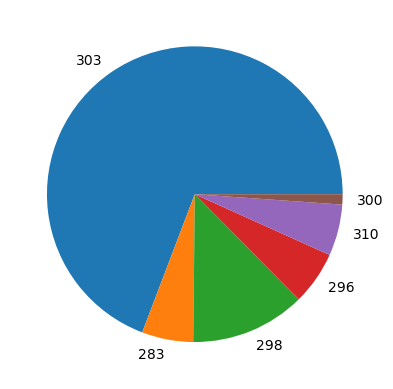

In [53]:
#db_data.pie_temperature()
import collections
temps = [ int(float(system['TEMPERATURE'])) for system in systems]
counter = collections.Counter(temps)
plt.pie(counter.values(),labels=counter.keys());

<Figure size 640x480 with 0 Axes>

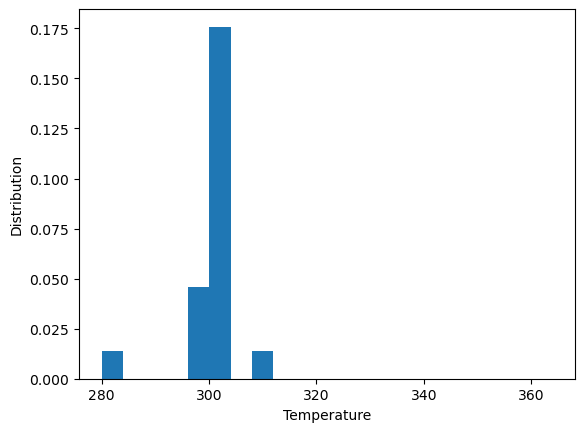

<Figure size 640x480 with 0 Axes>

In [54]:
distTemps = plt.hist(temps, density=True, bins=np.arange(280,365,4))
plt.xlabel('Temperature')
plt.ylabel('Distribution')
plt.figure()

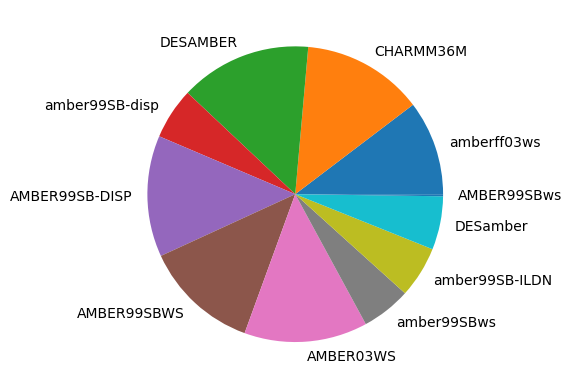

In [55]:

temps = [ s['FF'] for s in systems if 'FF' in s]
counter = collections.Counter(temps)
plt.pie(counter.values(),labels=counter.keys());

{'AMBER99SBws': 1}


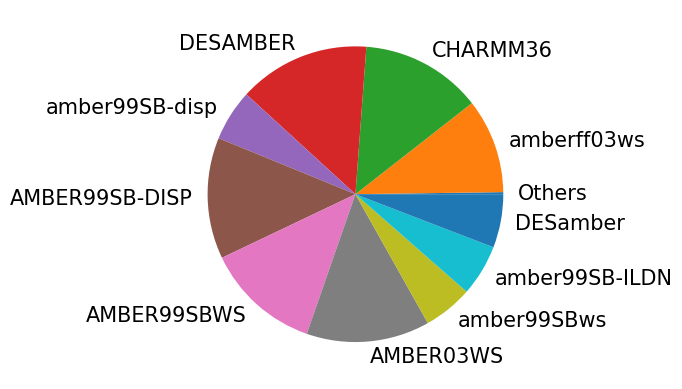

In [56]:
ffs = []

for system in systems:
    try:
        ff = system['FF']
    except:
        print('Force field information missing from' + system['path'])
    
    if 'GROMOS-CKP' in ff or 'gromos-ckp' in ff:
        ffs.append('GROMOS-CKP')
    elif 'Charmm-Drude' in ff:
        ffs.append('Charmm-Drude')
    elif 'Berger' in ff:
        ffs.append('Berger')    
    elif 'Slipids' in ff or 'slipids' in ff:
        ffs.append('Slipids')    
    elif 'lipid17ecc' in ff or 'ECC-lipids' in ff:
        ffs.append('ECClipids')
    elif 'ECC-CHARMM36' in ff:
        ffs.append(ff)
    elif 'CHARMM36' in ff or 'Charmm36' in ff:
        ffs.append('CHARMM36')
    elif 'Lipid14' in ff or 'Lipid17' in ff or 'lipid17' in ff:
        ffs.append('Lipid14/17')
    elif 'Poger' in ff:
        ffs.append('Poger')
    else:
        ffs.append(ff)
    
counter = collections.Counter(ffs)
several = {}
several['Others'] = 0
less = {}
for i in counter:
    if counter[i] > 5:
        several[i] = counter[i]
    else:
        several['Others'] += counter[i] 
        less[i] = counter[i]
#plt.pie(counter.values(),labels=counter.keys(), textprops={'fontsize': 15});
plt.pie(several.values(),labels=several.keys(), textprops={'fontsize': 15});
#plt.savefig('../../../DataBankManuscriptText/Figures/FFpie.pdf', bbox_inches='tight')
print(less)